# GuidaPlate — Data Exploration
## NHANES 2017-2018 CKD Cohort Analysis
**Student:** ISIMBI TUZINDE Jade Keslie
**Supervisor:** Emmanuel Adjei
**Date:** June 2026

This notebook explores the NHANES 2017-2018
dataset to characterize the CKD patient cohort
used to train the GuidaPlate dietary risk
prediction models.


## Section 2 — Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline


## Section 3 — Load NHANES Data

Load four NHANES 2017-2018 (J cycle) CSV extracts from `data/raw/nhanes/`.


In [2]:
def project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / 'config.py').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Run from the GUIDAPLATE repository (config.py not found).')

ROOT = project_root()
NHANES_DIR = ROOT / 'data' / 'raw' / 'nhanes'
FIG_DIR = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

STAGE_ORDER = ['G2', 'G3a', 'G3b', 'G4']
STAGE_COLORS = {'G2': 'blue', 'G3a': 'orange', 'G3b': 'red', 'G4': 'darkred'}

dr1 = pd.read_csv(NHANES_DIR / 'DR1TOT_J.csv', low_memory=False)
dr2 = pd.read_csv(NHANES_DIR / 'DR2TOT_J.csv', low_memory=False)
bio = pd.read_csv(NHANES_DIR / 'BIOPRO_J.csv', low_memory=False)
demo = pd.read_csv(NHANES_DIR / 'DEMO_J.csv', low_memory=False)

for name, df in [('DR1TOT_J', dr1), ('DR2TOT_J', dr2), ('BIOPRO_J', bio), ('DEMO_J', demo)]:
    print(f'{name} shape: {df.shape}')
    display(df.head(3))


DR1TOT_J shape: (8704, 168)


,SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,...,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V
0,93703.0,5.397605e-79,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,8.171401e+04,82442.869214,1.0,49.0,2.0,2.0,7.0,2.0,1.0,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
2,93705.0,7.185561e+03,5640.391078,1.0,73.0,2.0,2.0,5.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


DR2TOT_J shape: (8704, 85)


,SEQN,WTDRD1,WTDR2D,DR2DRSTZ,DR2EXMER,DRABF,DRDINT,DR2DBIH,DR2DAY,DR2LANG,...,DR2TP184,DR2TP204,DR2TP205,DR2TP225,DR2TP226,DR2_300,DR2_320Z,DR2_330Z,DR2BWATZ,DR2TWSZ
0,93703.0,5.397605e-79,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,8.171401e+04,82442.869214,1.0,87.0,2.0,2.0,18.0,6.0,1.0,...,0.003,0.041,5.397605e-79,0.002,0.010,2.0,5.397605e-79,5.397605e-79,5.397605e-79,91.0
2,93705.0,7.185561e+03,5640.391078,1.0,91.0,2.0,2.0,15.0,4.0,1.0,...,0.001,0.201,2.000000e-03,0.011,0.059,2.0,9.600000e+02,5.397605e-79,9.600000e+02,1.0


BIOPRO_J shape: (6401, 41)


,SEQN,LBXSATSI,LBDSATLC,LBXSAL,LBDSALSI,LBXSAPSI,LBXSASSI,LBXSC3SI,LBXSBU,LBDSBUSI,...,LBXSCA,LBDSCASI,LBXSCH,LBDSCHSI,LBXSTP,LBDSTPSI,LBXSTR,LBDSTRSI,LBXSUA,LBDSUASI
0,93705.0,16.0,5.397605e-79,4.4,44.0,74.0,20.0,31.0,11.0,3.93,...,9.2,2.300,157.0,4.060,7.3,73.0,95.0,1.073,5.8,345.0
1,93706.0,10.0,5.397605e-79,4.4,44.0,79.0,14.0,28.0,12.0,4.28,...,9.6,2.400,149.0,3.853,7.1,71.0,92.0,1.039,8.0,475.8
2,93707.0,13.0,5.397605e-79,5.2,52.0,238.0,24.0,22.0,17.0,6.07,...,10.1,2.525,199.0,5.146,8.0,80.0,110.0,1.242,5.5,327.1


DEMO_J shape: (9254, 46)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82


## Section 4 — Merge and Filter

Merge all four files on `SEQN`, restrict to adults 18–80, and keep valid serum creatinine.


In [3]:
merged = demo.merge(bio, on='SEQN', how='inner')
merged = merged.merge(dr1, on='SEQN', how='inner')
merged = merged.merge(dr2, on='SEQN', how='inner')

shape_after_merge = merged.shape
print(f'Shape after merge: {shape_after_merge}')

merged = merged[(merged['RIDAGEYR'] >= 18) & (merged['RIDAGEYR'] <= 80)]
shape_after_age = merged.shape
print(f'Shape after age filter (18–80): {shape_after_age}')

merged = merged[merged['LBXSCR'] > 0]
shape_after_scr = merged.shape
print(f'Shape after LBXSCR > 0 filter: {shape_after_scr}')
print(f'Participants remaining: {len(merged):,}')


Shape after merge: (6401, 337)
Shape after age filter (18–80): (5533, 337)
Shape after LBXSCR > 0 filter: (5154, 337)
Participants remaining: 5,154


## Section 5 — Calculate eGFR

CKD-EPI 2021 creatinine-only equation (race-free). Filter to CKD cohort: eGFR 15–89 mL/min/1.73m².


In [4]:
def calculate_egfr(scr, age, sex):
    """CKD-EPI 2021 eGFR from serum creatinine (mg/dL), age (years), RIAGENDR (1=M, 2=F)."""
    scr = np.asarray(scr, dtype=float)
    age = np.asarray(age, dtype=float)
    sex = np.asarray(sex, dtype=float)
    egfr = np.empty_like(scr, dtype=float)

    female = sex == 2
    male = sex == 1

    # Females
    s, a = scr[female], age[female]
    e = np.where(
        s <= 0.7,
        142 * (s / 0.7) ** -0.241 * (0.9938 ** a),
        142 * (s / 0.7) ** -1.200 * (0.9938 ** a),
    )
    egfr[female] = e * 1.012

    # Males
    s, a = scr[male], age[male]
    egfr[male] = np.where(
        s <= 0.9,
        142 * (s / 0.9) ** -0.302 * (0.9938 ** a),
        142 * (s / 0.9) ** -1.200 * (0.9938 ** a),
    )
    return egfr

merged['eGFR'] = calculate_egfr(merged['LBXSCR'], merged['RIDAGEYR'], merged['RIAGENDR'])

ckd = merged[(merged['eGFR'] >= 15) & (merged['eGFR'] <= 89)].copy()
print(f'Final CKD cohort size: {len(ckd):,}')


Final CKD cohort size: 1,862


## Section 6 — Assign CKD Stages

KDIGO G-stages G2–G4 for eGFR 15–89.


In [5]:
def assign_ckd_stage(egfr):
    if 60 <= egfr <= 89:
        return 'G2'
    if 45 <= egfr < 60:
        return 'G3a'
    if 30 <= egfr < 45:
        return 'G3b'
    if 15 <= egfr < 30:
        return 'G4'
    return np.nan

ckd['ckd_stage'] = ckd['eGFR'].apply(assign_ckd_stage)
ckd = ckd.dropna(subset=['ckd_stage'])
ckd['ckd_stage'] = pd.Categorical(ckd['ckd_stage'], categories=STAGE_ORDER, ordered=True)

print('CKD stage distribution:')
print(ckd['ckd_stage'].value_counts().reindex(STAGE_ORDER))


CKD stage distribution:
ckd_stage
G2     1435
G3a     281
G3b     113
G4       33
Name: count, dtype: int64


## Section 7 — Average Nutrient Intake

Average Day 1 and Day 2 recalls; normalize protein to g/kg using body weight (`BMXWT`). If `BMX_J.csv` is unavailable, sex-specific NHANES median weights are used.


In [6]:
bmx_path = NHANES_DIR / 'BMX_J.csv'
if bmx_path.exists():
    bmx = pd.read_csv(bmx_path, usecols=['SEQN', 'BMXWT'])
    ckd = ckd.merge(bmx, on='SEQN', how='left')
    print('Merged body weight from BMX_J.csv')
else:
    print('Note: BMX_J.csv not found — using sex-specific NHANES median weights (kg).')
    ckd['BMXWT'] = ckd['RIAGENDR'].map({1: 88.3, 2: 74.0})

ckd['potassium'] = (ckd['DR1TPOTA'] + ckd['DR2TPOTA']) / 2
ckd['phosphorus'] = (ckd['DR1TPHOS'] + ckd['DR2TPHOS']) / 2
ckd['protein_raw'] = (ckd['DR1TPROT'] + ckd['DR2TPROT']) / 2
ckd['sodium'] = (ckd['DR1TSODI'] + ckd['DR2TSODI']) / 2
ckd['protein_per_kg'] = ckd['protein_raw'] / ckd['BMXWT']

nutrient_cols = ['potassium', 'phosphorus', 'protein_per_kg', 'sodium']
print('\nDescriptive statistics (participants with both recall days):')
display(ckd[nutrient_cols].describe())


Merged body weight from BMX_J.csv

Descriptive statistics (participants with both recall days):


,potassium,phosphorus,protein_per_kg,sodium
count,1490.000000,1490.000000,1476.000000,1490.000000
mean,2473.191275,1254.615101,0.917411,3142.294631
std,1045.331509,550.935389,0.437790,1415.046121
min,275.500000,87.000000,0.071046,431.000000
25%,1742.500000,880.000000,0.612159,2149.875000
50%,2334.250000,1166.250000,0.847255,2945.000000
75%,3054.375000,1562.500000,1.121684,3853.625000
max,9322.500000,4867.500000,4.227644,12055.500000


## Section 8 — Visualizations

Six exploratory plots saved to `outputs/figures/`.


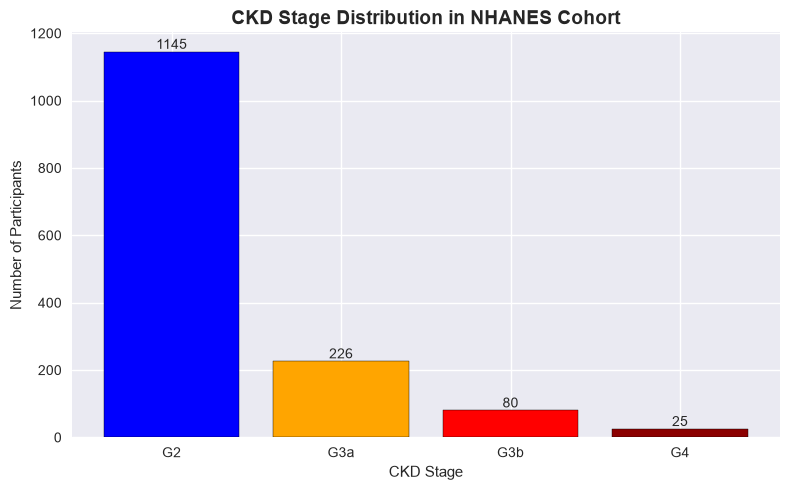

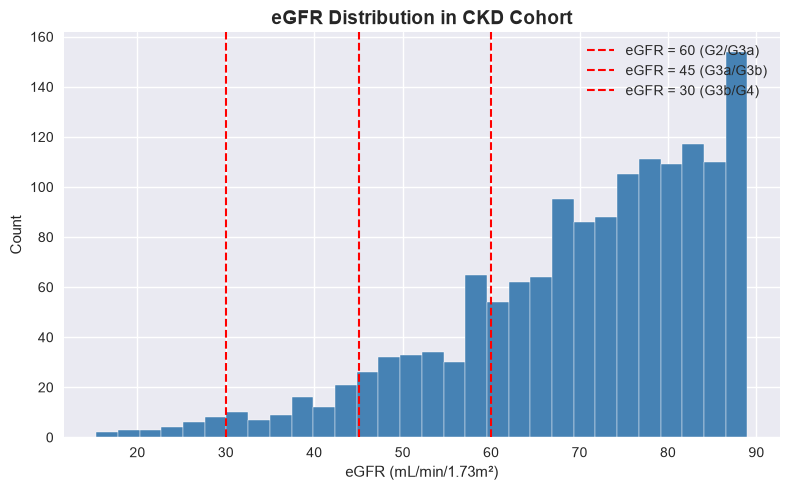

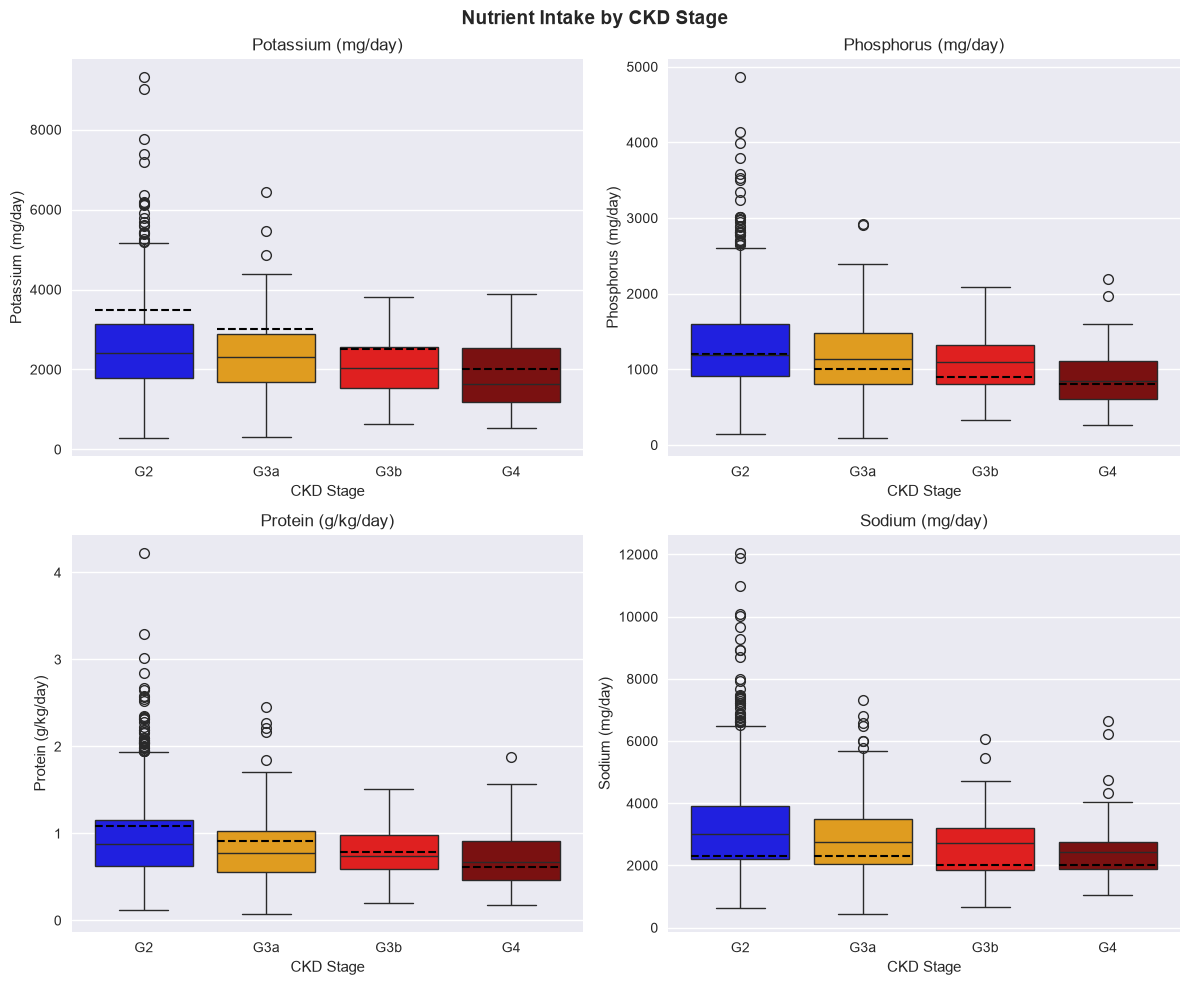

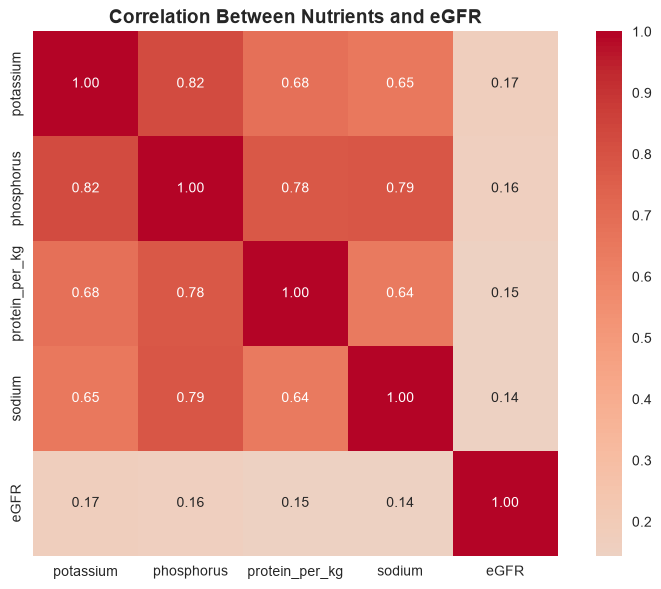

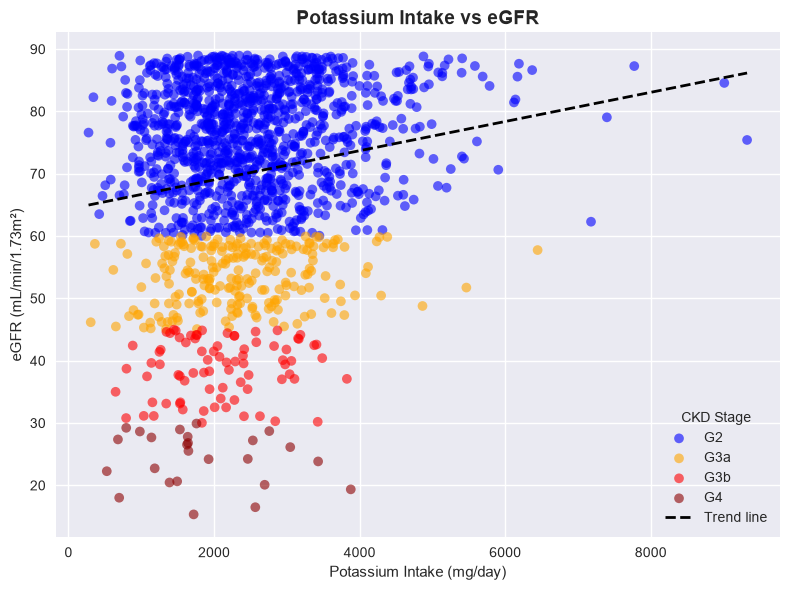

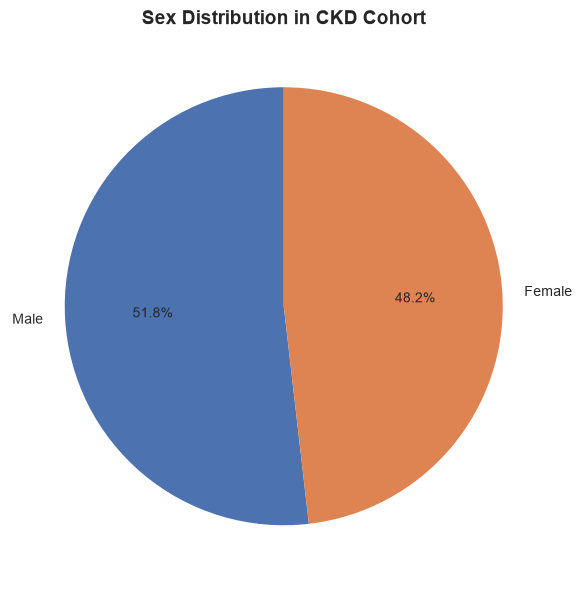

Figures saved to: /Users/jade/GUIDAPLATE/outputs/figures


In [7]:
KDOQI_THRESHOLDS = {
    'G2':  {'potassium': 3500, 'phosphorus': 1200, 'protein': 90,  'sodium': 2300},
    'G3a': {'potassium': 3000, 'phosphorus': 1000, 'protein': 75,  'sodium': 2300},
    'G3b': {'potassium': 2500, 'phosphorus': 900,  'protein': 65,  'sodium': 2000},
    'G4':  {'potassium': 2000, 'phosphorus': 800,  'protein': 56,  'sodium': 2000},
}

plot_df = ckd.dropna(subset=nutrient_cols).copy()

# PLOT 1 — CKD stage bar chart
fig, ax = plt.subplots(figsize=(8, 5))
counts = plot_df['ckd_stage'].value_counts().reindex(STAGE_ORDER)
bars = ax.bar(STAGE_ORDER, counts.values, color=[STAGE_COLORS[s] for s in STAGE_ORDER], edgecolor='black')
ax.set_title('CKD Stage Distribution in NHANES Cohort', fontsize=14, fontweight='bold')
ax.set_xlabel('CKD Stage')
ax.set_ylabel('Number of Participants')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(count)}', ha='center', va='bottom')
plt.tight_layout()
fig.savefig(FIG_DIR / '01_ckd_stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 2 — eGFR histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(plot_df['eGFR'], bins=30, color='steelblue', edgecolor='white')
for boundary, label in [(60, 'G2/G3a'), (45, 'G3a/G3b'), (30, 'G3b/G4')]:
    ax.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label=f'eGFR = {boundary} ({label})')
ax.set_title('eGFR Distribution in CKD Cohort', fontsize=14, fontweight='bold')
ax.set_xlabel('eGFR (mL/min/1.73m²)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / '02_egfr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 3 — Nutrient box plots by stage
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Nutrient Intake by CKD Stage', fontsize=14, fontweight='bold')

nutrient_labels = {
    'potassium': 'Potassium (mg/day)',
    'phosphorus': 'Phosphorus (mg/day)',
    'protein_per_kg': 'Protein (g/kg/day)',
    'sodium': 'Sodium (mg/day)',
}

for ax, nutrient in zip(axes.flatten(), nutrient_cols):
    sns.boxplot(data=plot_df, x='ckd_stage', y=nutrient, order=STAGE_ORDER,
                palette=STAGE_COLORS, ax=ax)
    ax.set_xlabel('CKD Stage')
    ax.set_ylabel(nutrient_labels[nutrient])
    ax.set_title(nutrient_labels[nutrient])

    for i, stage in enumerate(STAGE_ORDER):
        thr = KDOQI_THRESHOLDS[stage][nutrient if nutrient != 'protein_per_kg' else 'protein']
        if nutrient == 'protein_per_kg':
            median_wt = plot_df.loc[plot_df['ckd_stage'] == stage, 'BMXWT'].median()
            thr = thr / median_wt if median_wt and median_wt > 0 else thr / 80.0
        ax.hlines(thr, i - 0.4, i + 0.4, colors='black', linestyles='--', linewidth=1.5)

plt.tight_layout()
fig.savefig(FIG_DIR / '03_nutrient_intake_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 4 — Correlation heatmap
corr_vars = ['potassium', 'phosphorus', 'protein_per_kg', 'sodium', 'eGFR']
corr = plot_df[corr_vars].corr(method='pearson')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Between Nutrients and eGFR', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / '04_nutrient_egfr_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 5 — Potassium vs eGFR scatter
fig, ax = plt.subplots(figsize=(8, 6))
for stage in STAGE_ORDER:
    subset = plot_df[plot_df['ckd_stage'] == stage]
    ax.scatter(subset['potassium'], subset['eGFR'], c=STAGE_COLORS[stage], label=stage, alpha=0.6, edgecolors='none')
z = np.polyfit(plot_df['potassium'], plot_df['eGFR'], 1)
x_line = np.linspace(plot_df['potassium'].min(), plot_df['potassium'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='black', linestyle='--', linewidth=2, label='Trend line')
ax.set_title('Potassium Intake vs eGFR', fontsize=14, fontweight='bold')
ax.set_xlabel('Potassium Intake (mg/day)')
ax.set_ylabel('eGFR (mL/min/1.73m²)')
ax.legend(title='CKD Stage')
plt.tight_layout()
fig.savefig(FIG_DIR / '05_potassium_vs_egfr.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 6 — Sex distribution pie chart
fig, ax = plt.subplots(figsize=(6, 6))
sex_labels = plot_df['RIAGENDR'].map({1: 'Male', 2: 'Female'})
sex_counts = sex_labels.value_counts()
ax.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('Sex Distribution in CKD Cohort', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / '06_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Figures saved to: {FIG_DIR}')


## Section 9 — Food Database Preview

Load the verified 50-food Rwanda composition table from `backend/data/food_database.csv`.


Food database shape: (386, 15)


,food_id,english,french,kinyarwanda,category,meal_type,protein_g,potassium_mg,phosphorus_mg,sodium_mg,energy_kcal,preparation_method,source,ckd_stage_safe,notes
0,1,sweet potatoes,Patate douce,Ibijumba,Starch,Any,1.10,101.0,25.0,4.0,101.0,boiled,Kenya FCT 2018,1-3,"High potassium 311mg — restrict stages 4,5"
1,2,cassava,Manioc,Imyumbati,Starch,Lunch/Dinner,0.60,171.0,17.0,2.0,148.0,boiled,Kenya FCT 2018,1-4,Moderate potassium 250mg — limit at stage 5
2,3,Irish potatoes,Pomme de terre,Ibirayi,Starch,Any,2.00,544.0,44.0,7.0,77.0,boiled/fried,USDA FDC,1-2,"Very high potassium 544mg — restrict stages 3,4,5"
3,4,banana,Banane,Umuneke,Starch,Any,0.73,358.0,22.0,1.0,89.0,raw,USDA FDC,1-3,"High potassium 358mg — restrict stages 4,5"
4,5,maize,Maïs,Ibigori,Grain,Breakfast/Any,2.90,226.0,73.0,2.0,146.0,boiled,Kenya FCT 2018,1-4,Moderate potassium 226mg — limit at stage 5
5,6,rice,Riz,Umuceri,Grain,Lunch/Dinner,2.30,20.0,48.0,0.0,119.0,boiled,Kenya FCT 2018,1-5,Safe all stages — low nutrient content
6,7,sorghum,Sorgho,Amasaka,Grain,Breakfast/Any,3.40,129.0,117.0,2.0,140.0,boiled,Kenya FCT 2018,1-5,Safe all stages — low nutrient content
7,8,wheat,Blé,Ingano,Grain,Any,12.20,358.0,346.0,2.0,328.0,ground,Kenya FCT 2018,1-3,"High potassium 358mg — restrict stages 4,5"
8,9,milk,Lait,Amata,Dairy,Any,3.20,136.0,96.0,46.0,70.0,raw,Kenya FCT 2018,1-5,Safe all stages — low nutrient content
9,10,beef meat,Bœuf,Inyama y'inka,Meat,Lunch/Dinner,28.70,230.0,194.0,67.0,197.0,boiled,Kenya FCT 2018,1-4,Moderate potassium 241mg — limit at stage 5


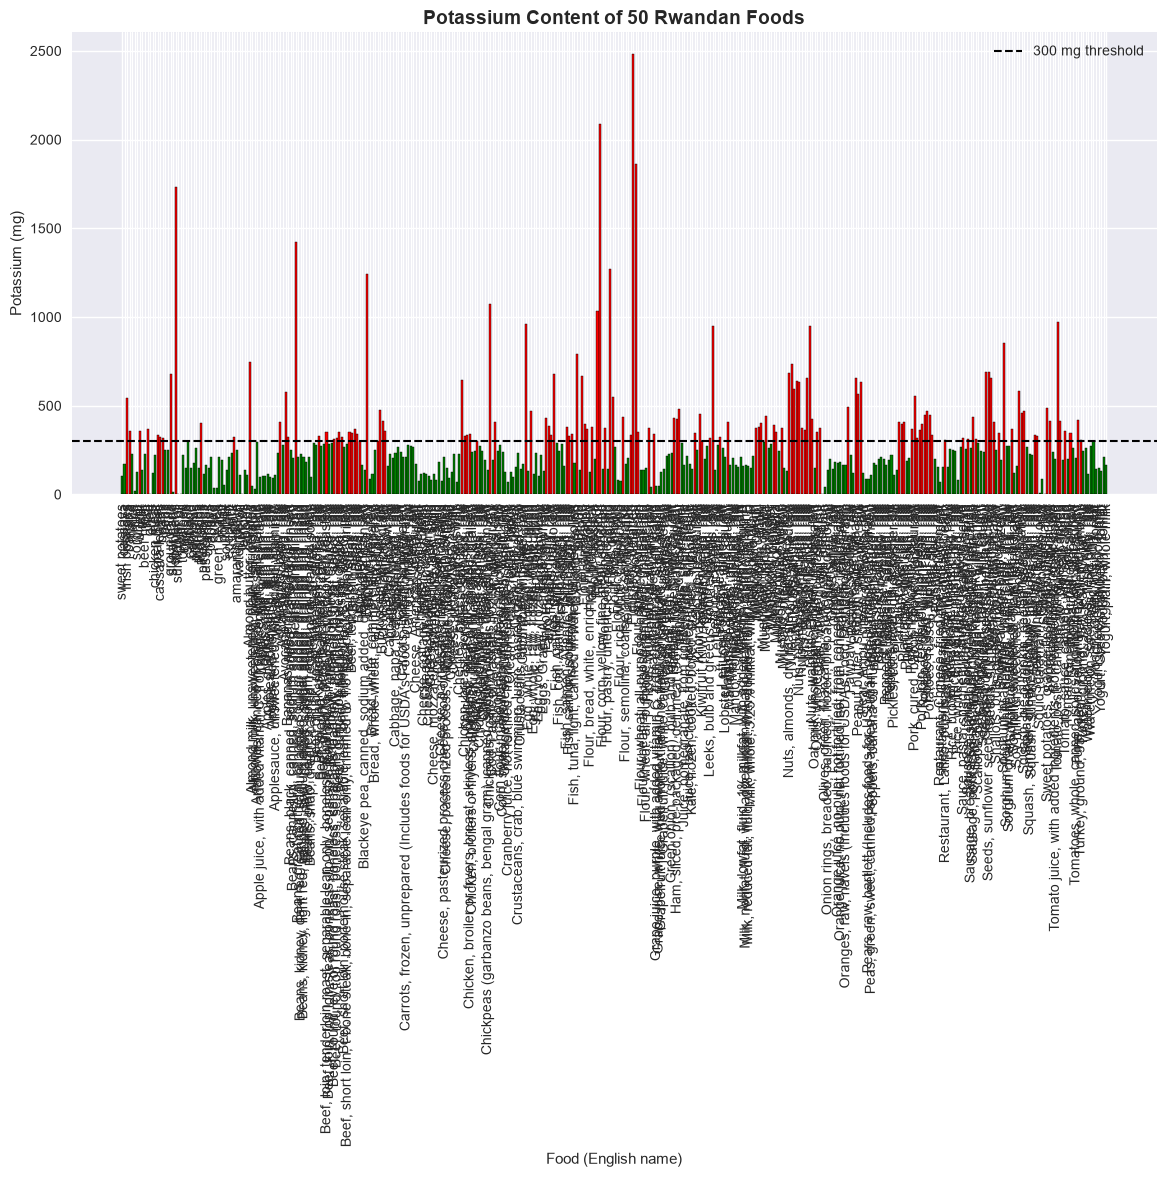

In [8]:
food_db = pd.read_csv(ROOT / 'backend' / 'data' / 'food_database.csv')
print(f'Food database shape: {food_db.shape}')
display(food_db.head(10))

fig, ax = plt.subplots(figsize=(14, 6))
colors = np.where(food_db['potassium_mg'] > 300, 'red', 'green')
ax.bar(food_db['english'], food_db['potassium_mg'], color=colors, edgecolor='black')
ax.axhline(300, color='black', linestyle='--', linewidth=1.5, label='300 mg threshold')
ax.set_title('Potassium Content of 50 Rwandan Foods', fontsize=14, fontweight='bold')
ax.set_xlabel('Food (English name)')
ax.set_ylabel('Potassium (mg)')
plt.xticks(rotation=90)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / '07_rwandan_food_potassium.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Summary


In [9]:
from IPython.display import Markdown, display

stage_counts = ckd['ckd_stage'].value_counts().reindex(STAGE_ORDER)
total_ckd = len(ckd)
pct = (stage_counts / total_ckd * 100).round(1)

summary_md = f"""
## Key Findings

- Total NHANES participants merged: {shape_after_merge[0]:,}
- CKD cohort size: {total_ckd:,}
- Stage G2: {int(stage_counts['G2']):,} participants ({pct['G2']}%)
- Stage G3a: {int(stage_counts['G3a']):,} participants ({pct['G3a']}%)
- Stage G3b: {int(stage_counts['G3b']):,} participants ({pct['G3b']}%)
- Stage G4: {int(stage_counts['G4']):,} participants ({pct['G4']}%)

These findings justify the stage-specific
dietary risk architecture of GuidaPlate.
"""

display(Markdown(summary_md))



## Key Findings

- Total NHANES participants merged: 6,401
- CKD cohort size: 1,862
- Stage G2: 1,435 participants (77.1%)
- Stage G3a: 281 participants (15.1%)
- Stage G3b: 113 participants (6.1%)
- Stage G4: 33 participants (1.8%)

These findings justify the stage-specific
dietary risk architecture of GuidaPlate.


In [10]:
# ─────────────────────────────────────
# Export CKD cohort for statistical
# analysis in notebook 03
# ─────────────────────────────────────

import os
os.makedirs('data/processed',
            exist_ok=True)

# Select only columns needed
# for the 5 statistical tests
cohort_export = ckd[[
    'SEQN',
    'RIDAGEYR',
    'RIAGENDR',
    'BMXWT',
    'eGFR',
    'ckd_stage',
    'potassium',
    'phosphorus',
    'protein_per_kg',
    'sodium'
]].copy()

# Rename to clean column names
cohort_export = cohort_export.rename(
    columns={
        'RIDAGEYR':    'age',
        'RIAGENDR':    'sex',
        'BMXWT':       'weight_kg'
    }
)

# Save to CSV
save_path = 'data/processed/ckd_cohort_final.csv'
cohort_export.to_csv(
    save_path,
    index=False
)

# Verify
print("=" * 40)
print("CKD COHORT EXPORT COMPLETE")
print("=" * 40)
print(f"File: {save_path}")
print(f"Rows: {len(cohort_export)}")
print(f"Columns: {cohort_export.columns.tolist()}")
print()
print("Stage distribution:")
print(cohort_export['ckd_stage']
      .value_counts()
      .reindex(['G2','G3a','G3b','G4']))
print()
print("Nutrient summary:")
print(cohort_export[[
    'potassium',
    'phosphorus',
    'protein_per_kg',
    'sodium'
]].describe().round(2))
print()
print("First 3 rows:")
print(cohort_export.head(3))
print()
print("Saved successfully.")

CKD COHORT EXPORT COMPLETE
File: data/processed/ckd_cohort_final.csv
Rows: 1862
Columns: ['SEQN', 'age', 'sex', 'weight_kg', 'eGFR', 'ckd_stage', 'potassium', 'phosphorus', 'protein_per_kg', 'sodium']

Stage distribution:
ckd_stage
G2     1435
G3a     281
G3b     113
G4       33
Name: count, dtype: int64

Nutrient summary:
       potassium  phosphorus  protein_per_kg    sodium
count    1490.00     1490.00         1476.00   1490.00
mean     2473.19     1254.62            0.92   3142.29
std      1045.33      550.94            0.44   1415.05
min       275.50       87.00            0.07    431.00
25%      1742.50      880.00            0.61   2149.88
50%      2334.25     1166.25            0.85   2945.00
75%      3054.38     1562.50            1.12   3853.62
max      9322.50     4867.50            4.23  12055.50

First 3 rows:
      SEQN   age  sex  weight_kg       eGFR ckd_stage  potassium  phosphorus  \
0  93705.0  66.0  2.0       79.5  68.671196        G2     1399.0       602.0   
1  93